# Synthetic Au multispectral Bayes

Demo (no hardware). A RandomForest oracle maps flows
`au, ag, peg, ctab, cit, pvp, ascorb, teos` to UV/SAXS descriptors
`uv1, uv2, saxs1, saxs2` (trained on `examples/Au_multispectral/data/training_ready.csv`).

Two modes:

1. **Uncertainty** — `UncertaintySuggester` (`max_variance`), plot epistemic std vs iteration.
2. **Target** — `ScalarEISuggester` maximizes similarity to a chosen `(uv1*, uv2*, saxs1*, saxs2*)`.


## 1. Setup


In [29]:
import sys
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

HERE = Path.cwd()
if HERE.name != "Au_multispectral_synthetic":
    HERE = HERE / "examples" / "Au_multispectral_synthetic"
sys.path.insert(0, str(HERE.parents[1]))

from bayesian_optimization import DesignSpace, ScalarEISuggester, UncertaintySuggester

FLOW = ["au", "ag", "peg", "ctab", "cit", "pvp", "ascorb", "teos"]
TARGETS = ["uv1", "uv2", "saxs1", "saxs2"]
full = pd.read_csv(HERE.parents[1] / "examples/Au_multispectral/data/training_ready.csv").dropna(subset=FLOW + TARGETS)

space = DesignSpace(
    names=FLOW,
    bounds={
        "au": (3.3, 8.5), "peg": (1e-3, 19.999), "ctab": (1e-3, 19.999),
        "cit": (1e-3, 19.999), "pvp": (1e-3, 19.999),
        "ag": (0.0, 1.0), "ascorb": (0.0, 20.0), "teos": (0.0, 1.0),
    },
    sum_equals=20.0, fixed={"ag": 0.0, "teos": 0.0},
    linear_deps={"ascorb": {"au": 1.2, "ag": 1.2}},
)

X_all, Y_all = full[FLOW].to_numpy(float), full[TARGETS].to_numpy(float)
rf = MultiOutputRegressor(RandomForestRegressor(n_estimators=500, max_depth=4, min_samples_leaf=2, random_state=42, n_jobs=-1)).fit(X_all, Y_all)
noise = np.maximum(0.02 * Y_all.std(0), 1e-4)
rng = np.random.default_rng(42)

def measure(x):
    mu = rf.predict(np.asarray(x, float).reshape(1, -1))[0]
    return mu + rng.normal(0, noise)


## 2. Uncertainty mode

Start from IHS rows. Each step: `UncertaintySuggester` proposes 1 point → oracle measures → append.
Plot total epistemic std of the next suggestion.


In [30]:
ihs = full[full["dataset"].eq("IHS")]
X = ihs[FLOW].to_numpy(float)
Y = ihs[TARGETS].to_numpy(float)
iters, Us = [], []

for it in range(0, 25):
    sug = UncertaintySuggester(
        space, acquisition="max_variance", n_candidates=2000, training_iter=80,
        seed=42, output_names=TARGETS,
    )
    x = sug.suggest(X, Y, n_points=1)[0]
    u = float(sug.last_candidate_table.loc[sug.last_candidate_table["picked"], "uncertainty_score"].iloc[0])
    iters.append(it); Us.append(u)
    print(f"{it:2d}  U={u:.3f}", flush=True)
    if it == 0:
        continue
    X = np.vstack([X, x]); Y = np.vstack([Y, measure(x)])


 0  U=3.909
 1  U=3.909
 2  U=3.768
 3  U=4.639
 4  U=3.975
 5  U=3.290
 6  U=3.389
 7  U=3.037
 8  U=3.274
 9  U=2.755
10  U=3.642
11  U=2.906
12  U=2.927
13  U=2.849
14  U=2.188
15  U=2.744
16  U=2.377
17  U=2.928
18  U=2.436
19  U=2.249
20  U=2.174
21  U=2.265
22  U=2.076
23  U=1.891
24  U=1.988


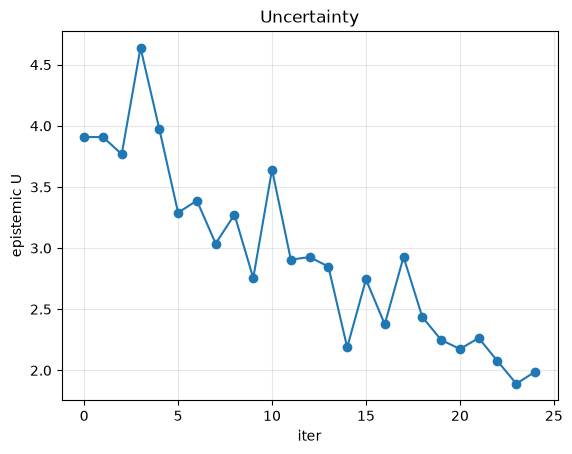

In [31]:
plt.plot(iters, Us, "-o")
plt.xlabel("iter"); plt.ylabel("epistemic U"); plt.title("Uncertainty")
plt.grid(alpha=0.3); plt.show()


## 3. Target UV / SAXS mode

Choose a descriptor target `Y*`. Score = negative standardized RMSE vs oracle measurement;
`ScalarEISuggester` maximizes that score.


In [27]:
Y_STAR = np.array([0.70, 2.00, 0.25, -2.50])
scale = np.where(Y_all.std(0) < 1e-8, 1.0, Y_all.std(0))

def pred(x):
    return rf.predict(np.asarray(x, float).reshape(1, -1))[0]

def score(x):
    return -float(np.sqrt((((pred(x) - Y_STAR) / scale) ** 2).mean()))

def fmt_x(x):
    return {k: round(float(v), 3) for k, v in zip(FLOW, x)}

X = space.sample_feasible(8, seed=7)
y = np.array([score(x) for x in X])
ei = ScalarEISuggester(space, maximize=True, random_state=0)
best = float(y.max())
x_best = X[int(y.argmax())]
hist = []
print(f"LHS best={best:.3f}  x={fmt_x(x_best)}  y={np.round(pred(x_best), 3)}  Y*={Y_STAR}", flush=True)

for it in range(1, 13):
    x = ei.suggest(X, y, n_points=1)[0]
    s = score(x)
    X = np.vstack([X, x]); y = np.append(y, s)
    if s > best:
        best, x_best = float(s), x.copy()
        print(f"{it:2d}  score={s:.3f}  NEW best  x={fmt_x(x_best)}  y={np.round(pred(x_best), 3)}  Y*={Y_STAR}", flush=True)
    else:
        print(f"{it:2d}  score={s:.3f}  best={best:.3f}", flush=True)
    hist.append((it, s, best))


LHS best=-0.407  x={'au': 4.876, 'ag': 0.0, 'peg': 0.694, 'ctab': 2.001, 'cit': 2.388, 'pvp': 4.19, 'ascorb': 5.851, 'teos': 0.0}  y=[ 0.62   2.786  0.292 -2.608]  Y*=[ 0.7   2.    0.25 -2.5 ]
 1  score=-0.510  best=-0.407
 2  score=-0.506  best=-0.407
 3  score=-0.425  best=-0.407
 4  score=-0.445  best=-0.407
 5  score=-0.489  best=-0.407
 6  score=-0.281  NEW best  x={'au': 6.087, 'ag': 0.0, 'peg': 5.2, 'ctab': 0.001, 'cit': 0.001, 'pvp': 1.407, 'ascorb': 7.304, 'teos': 0.0}  y=[ 0.644  1.853  0.192 -2.824]  Y*=[ 0.7   2.    0.25 -2.5 ]
 7  score=-0.281  best=-0.281
 8  score=-0.324  best=-0.281
 9  score=-0.355  best=-0.281
10  score=-0.251  NEW best  x={'au': 6.105, 'ag': 0.0, 'peg': 1.915, 'ctab': 0.001, 'cit': 0.001, 'pvp': 4.652, 'ascorb': 7.326, 'teos': 0.0}  y=[ 0.653  1.839  0.184 -2.749]  Y*=[ 0.7   2.    0.25 -2.5 ]
11  score=-0.478  best=-0.251
12  score=-0.410  best=-0.251


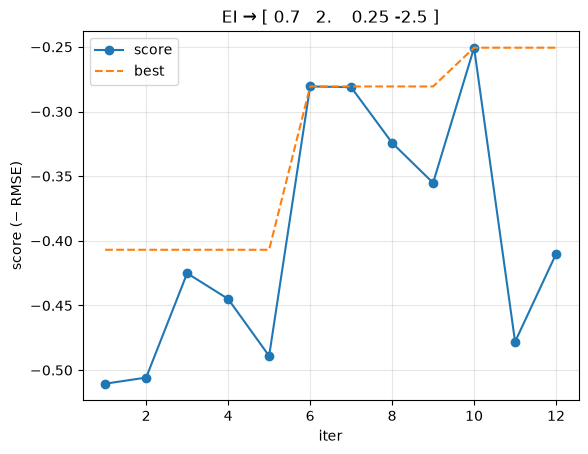

In [28]:
it, sc, bs = zip(*hist)
plt.plot(it, sc, "-o", label="score")
plt.plot(it, bs, "--", label="best")
plt.xlabel("iter"); plt.ylabel("score (− RMSE)"); plt.legend(); plt.grid(alpha=0.3)
plt.title(f"EI → {Y_STAR}"); plt.show()
